In [1]:
import scanpy as sc
import numpy as np
import pandas as pd

import sys
sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
import matplotlib.pyplot as plt

large_data_dir = gf_utils.large_data_dir

color_palette = {'K562':'#F79520', 'SET2':'#1c75bc', 'HEL':'#39b54a'}

In [ ]:
### read in unfiltered flex single cell data
adata_path = large_data_dir + 'cr_CL3_HB_Betaine_sample_filtered_feature_bc_matrix.h5'
adata_sc = sc.read_10x_h5(adata_path)

### read in processed single cell adata to get cell type annotations and filtered cells
cell_metadata = sc.read_h5ad(large_data_dir + 'CL3_HB_Betaine_0bp_genotype_GF.h5ad').obs
cell_metadata = cell_metadata.loc[(cell_metadata['BC'] == 'CL3_HB_Betaine_BC001')]['cell_type']

### then filter and add cell types
adata_sc = adata_sc[cell_metadata.index,:].copy()
adata_sc.obs['cell_type'] = cell_metadata


In [ ]:
### read in unfiltered spatial adata
adata_spatial = sc.read_10x_h5(f"{large_data_dir}gf_CL_VisiumHD/GapFill_WTA/outs/binned_outputs/square_016um/filtered_feature_bc_matrix.h5")

### read in processed spatial metadata to get cell type annotations and filtered spots
spatial_metadata = pd.read_csv('../output/visium_gapfill_counts_by_cell_line_unaggregated_square_016um.csv.gz')
spatial_metadata = spatial_metadata[['Barcode','Cell Line']].drop_duplicates().set_index('Barcode')['Cell Line']

### then filter and add cell types
adata_spatial = adata_spatial[spatial_metadata.index,:].copy()
adata_spatial.obs['cell_type'] = spatial_metadata

In [4]:
### filter to only genes present in both datasets
genes_to_include = adata_spatial.var_names.intersection(adata_sc.var_names)

adata_sc = adata_sc[:,genes_to_include].copy()
adata_spatial = adata_spatial[:,genes_to_include].copy()

### concatenate the two datasets
adata = sc.concat([adata_sc, adata_spatial], label='platform', keys=['flex', 'visium'], join='inner')

sc.pp.calculate_qc_metrics(adata, inplace = True)


/data1/lareauc/users/blattms/miniconda3/envs/gift_paper/lib/python3.11/site-packages/scanpy/plotting/_anndata.py:967: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


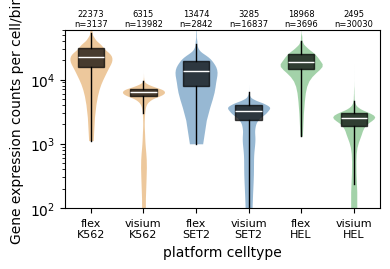

In [5]:
adata.obs['platform_celltype'] = adata.obs['platform'].astype(str) + '_' + adata.obs['cell_type'].astype(str)
adata.obs['platform_celltype'] = pd.Categorical(
    adata.obs['platform_celltype'],
    categories=['flex_K562', 'visium_K562', 'flex_SET2', 'visium_SET2', 'flex_HEL', 'visium_HEL'],
    ordered=True
)

# Build palette for combined groups
palette = {}
for ct in adata.obs['cell_type'].unique():
    palette[f'flex_{ct}'] = color_palette[ct]
    palette[f'visium_{ct}'] =  color_palette[ct]

fig, ax = plt.subplots(figsize=(4,2.8))

to_plot = 'total_counts'
sc.pl.violin(adata, keys=to_plot, groupby='platform_celltype', ax=ax, show=False, alpha=0.5, jitter=False, inner='box', palette=palette, linewidth=0, stripplot=False)

groups = adata.obs['platform_celltype'].cat.categories if hasattr(adata.obs['platform_celltype'], 'cat') else adata.obs['platform_celltype'].unique()
# Match the order used by scanpy's violin plot
ordered_groups = list(groups)
for i, group in enumerate(ordered_groups):
    data = adata[adata.obs['platform_celltype'] == group].obs[to_plot]
    bp = ax.boxplot([data], positions=[i], widths=0.5, showfliers=False, 
                     patch_artist=True, boxprops=dict(facecolor='k', alpha=0.7),
                     medianprops=dict(color='white', linewidth=1),
                     capprops=dict(linewidth=0))
    median_val = data.median()
    n = len(data)
    ax.text(i, 62000, f'{median_val:.0f}\nn={n}', ha='center', va='bottom', fontsize=6, color='black')

ax.set_ylim(0,60000)
ax.set_ylabel('Gene expression counts per cell/bin')

ax.set_xticks(range(len(ordered_groups)))
ax.set_xticklabels([g.replace('_', '\n') for g in ordered_groups], rotation=0, fontsize=8)

ax.set_yscale('log')
ax.set_ylim(100, 60000)

plt.tight_layout()
plt.savefig('../plots/wta_counts_boxplot.pdf')

In [6]:
### get gapfill counts for flex and visium

visium_counts = pd.read_csv('../output/visium_gapfill_counts_by_cell_line_unaggregated_square_016um.csv.gz')
visium_counts['GF Probe'] = visium_counts['GF Probe'].replace('KRAS c.35G>*', 'KRAS c.34G>T')

flex_counts = pd.read_csv('../../1_figure_CL_proof_of_concept/output/gapfill_betaine_probe_counts_unaggregated.csv', index_col=0)
## subset to correct gapfills
flex_counts = flex_counts.loc[flex_counts['correct'] == True, :].copy()

### filter to gapfill probes present in both datasets
flex_gf_probes = flex_counts['name'].unique()
visium_gf_probes = visium_counts['GF Probe'].unique()

included_probes = set(visium_gf_probes).intersection(set(flex_gf_probes))

flex_counts = flex_counts.loc[flex_counts['name'].isin(included_probes)]
visium_counts = visium_counts.loc[visium_counts['GF Probe'].isin(included_probes)]

In [7]:
flex_gf_counts_per_cell = flex_counts.groupby('barcode')['count'].sum()
visium_gf_counts_per_cell = visium_counts.groupby('Barcode')['Correct Gapfill Counts'].sum()

adata.obs['gapfill_counts_per_cell'] = pd.concat([flex_gf_counts_per_cell,visium_gf_counts_per_cell])

/data1/lareauc/users/blattms/miniconda3/envs/gift_paper/lib/python3.11/site-packages/scanpy/plotting/_anndata.py:967: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


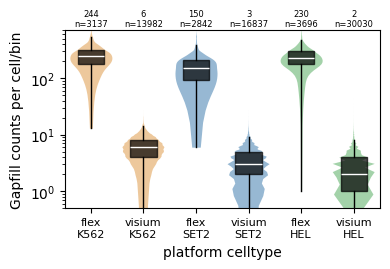

In [8]:
fig, ax = plt.subplots(figsize=(4,2.8))

to_plot = 'gapfill_counts_per_cell'
sc.pl.violin(adata, keys=to_plot, groupby='platform_celltype', ax=ax, show=False, alpha=0.5, jitter=False, inner='box', palette=palette, linewidth=0, stripplot=False)

groups = adata.obs['platform_celltype'].cat.categories if hasattr(adata.obs['platform_celltype'], 'cat') else adata.obs['platform_celltype'].unique()
# Match the order used by scanpy's violin plot
ordered_groups = list(groups)
for i, group in enumerate(ordered_groups):
    data = adata[adata.obs['platform_celltype'] == group].obs[to_plot]
    bp = ax.boxplot([data], positions=[i], widths=0.5, showfliers=False, 
                     patch_artist=True, boxprops=dict(facecolor='k', alpha=0.7),
                     medianprops=dict(color='white', linewidth=1),
                     capprops=dict(linewidth=0))
    median_val = data.median()
    n = len(data)
    ax.text(i, 750, f'{median_val:.0f}\nn={n}', ha='center', va='bottom', fontsize=6, color='black')

ax.set_ylim(-5,700)
ax.set_ylabel('Gapfill counts per cell/bin')

ax.set_xticks(range(len(ordered_groups)))
ax.set_xticklabels([g.replace('_', '\n') for g in ordered_groups], rotation=0, fontsize=8)

ax.set_yscale('log')
ax.set_ylim(0.5, 700)
plt.tight_layout()
plt.savefig('../plots/gapfill_counts_boxplot.pdf')